# Explore here

In [1]:
# Paso 1: Carga del conjunto de datos
import pandas as pd

# Cargamos el dataset directamente desde el enlace 
url = "https://breathecode.herokuapp.com/asset/internal-link?id=2326&path=adult-census-income.csv"
df = pd.read_csv(url)

# Comprobamos que se cargó bien
print("Filas y columnas:", df.shape)
df.head()

Filas y columnas: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [2]:
# Paso 2.1: Detectar valores nulos / mal codificados
import numpy as np

df = df.replace("?", np.nan)

# Contamos cuántos nulos hay por columna
nulos = df.isnull().sum()
print(nulos)

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64


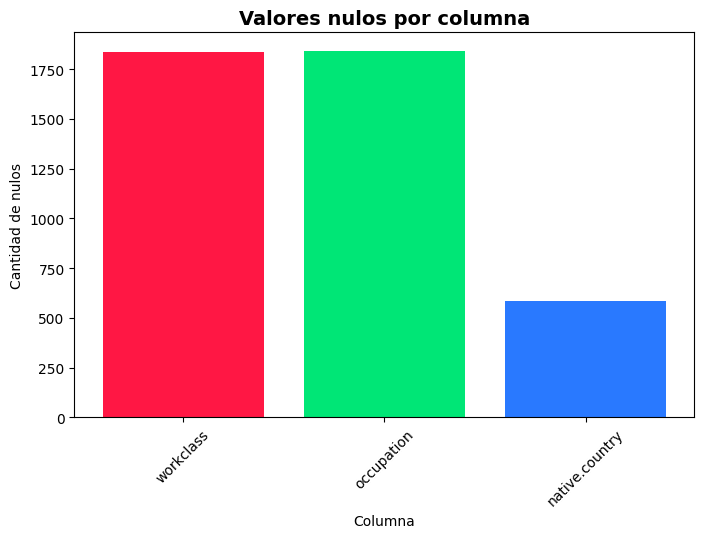

In [3]:
import matplotlib.pyplot as plt

nulos_con_datos = nulos[nulos > 0]

colores = ["#FF1744", "#00E676", "#2979FF"]

plt.figure(figsize=(8, 5))
plt.bar(nulos_con_datos.index, nulos_con_datos.values, color=colores)
plt.title("Valores nulos por columna", fontsize=14, fontweight="bold")
plt.xlabel("Columna")
plt.ylabel("Cantidad de nulos")
plt.xticks(rotation=45)
plt.show()

In [4]:
# Paso 2.2: Limpieza de valores nulos

for columna in ["workclass", "occupation", "native.country"]:
    moda = df[columna].mode()[0]
    df[columna] = df[columna].fillna(moda)

# Comprobamos que ya no quedan nulos
print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64


In [5]:
# Paso 2.3: Transformación de variables categóricas
from sklearn.preprocessing import LabelEncoder

df_original = df.copy()

# Buscamos las columnas categóricas
columnas_categoricas = df.select_dtypes(include="object").columns
print("Columnas categóricas:", list(columnas_categoricas))

encoder = LabelEncoder()
for columna in columnas_categoricas:
    df[columna] = encoder.fit_transform(df[columna])

# Vemos cómo quedó el dataset
df.head()

Columnas categóricas: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country', 'income']


/tmp/ipykernel_11673/3708440737.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas = df.select_dtypes(include="object").columns


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,3,77053,11,9,6,9,1,4,0,0,4356,40,38,0
1,82,3,132870,11,9,6,3,1,4,0,0,4356,18,38,0
2,66,3,186061,15,10,6,9,4,2,0,0,4356,40,38,0
3,54,3,140359,5,4,0,6,4,4,0,0,3900,40,38,0
4,41,3,264663,15,10,5,9,3,4,0,0,3900,40,38,0


In [6]:
# Paso 2.4: Normalización de las variables numéricas
from sklearn.preprocessing import MinMaxScaler

columnas_numericas = ["age", "fnlwgt", "education.num",
                      "capital.gain", "capital.loss", "hours.per.week"]

scaler = MinMaxScaler()
df[columnas_numericas] = scaler.fit_transform(df[columnas_numericas])

# Vemos cómo quedó
df[columnas_numericas].head()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
0,1.000000,0.043987,0.533333,0.0,1.000000,0.397959
1,0.890411,0.081896,0.533333,0.0,1.000000,0.173469
2,0.671233,0.118021,0.600000,0.0,1.000000,0.397959
3,0.506849,0.086982,0.200000,0.0,0.895317,0.397959
4,0.328767,0.171404,0.600000,0.0,0.895317,0.397959


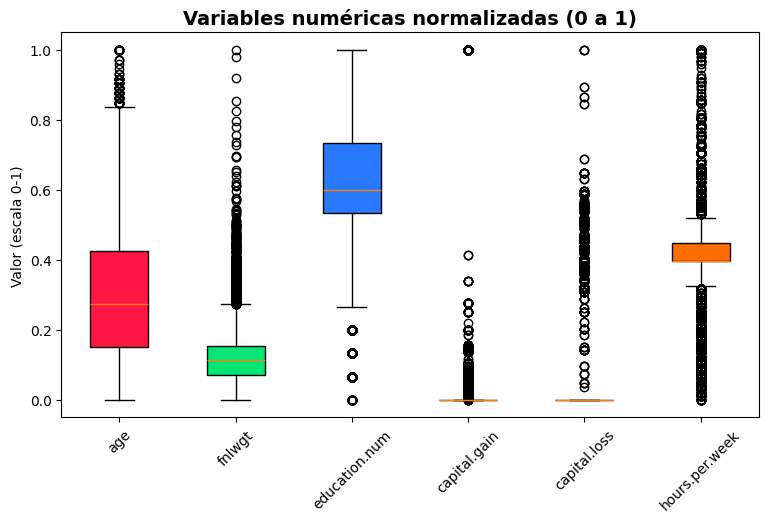

In [7]:
import matplotlib.pyplot as plt

colores = ["#FF1744", "#00E676", "#2979FF", "#FFEA00", "#D500F9", "#FF6D00"]

plt.figure(figsize=(9, 5))
caja = plt.boxplot([df[c] for c in columnas_numericas], patch_artist=True)

for parche, color in zip(caja["boxes"], colores):
    parche.set_facecolor(color)

plt.title("Variables numéricas normalizadas (0 a 1)", fontsize=14, fontweight="bold")
plt.ylabel("Valor (escala 0-1)")
plt.xticks(range(1, len(columnas_numericas) + 1), columnas_numericas, rotation=45)
plt.show()

In [8]:
# Paso 3: Definir el problema de recomendación.planteo como construir mi sistema de recomendacion.

# Paso 4.1: Preparamos los datos para el sistema de recomendación

columnas_perfil = df.drop(columns=["income", "fnlwgt"]).columns

# Separamos a los usuarios según su ingreso
alto_ingreso = df[df["income"] == 1]   
bajo_ingreso = df[df["income"] == 0]   

print("Variables del perfil:", list(columnas_perfil))
print("Usuarios con >50K:", len(alto_ingreso))
print("Usuarios con <=50K:", len(bajo_ingreso))



Variables del perfil: ['age', 'workclass', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country']
Usuarios con >50K: 7841
Usuarios con <=50K: 24720


In [9]:
# Paso 4.2: Creamos el modelo k-NN con los usuarios de alto ingreso
from sklearn.neighbors import NearestNeighbors

# Nos quedamos solo con el perfil de los usuarios que ganan >50K
X_alto = alto_ingreso[columnas_perfil]

# Creamos el modelo para buscar los 5 vecinos más parecidos
modelo = NearestNeighbors(n_neighbors=5)
modelo.fit(X_alto)

print("Modelo k-NN entrenado con", len(X_alto), "usuarios de alto ingreso")

Modelo k-NN entrenado con 7841 usuarios de alto ingreso


In [10]:
# Paso 4.3: Buscamos los vecinos parecidos de un usuario

usuario = bajo_ingreso[columnas_perfil].iloc[[0]]

# Buscamos 5 vecinos más parecidos que SÍ ganan >50K
distancias, indices = modelo.kneighbors(usuario)

# Recuperamos esos vecinos
vecinos = alto_ingreso.iloc[indices[0]]

# Columnas que nos interesa comparar 
columnas_a_mirar = ["education", "occupation", "hours.per.week", "workclass"]

print(">>> PERFIL DEL USUARIO (gana <=50K):")
print(df_original.loc[usuario.index, columnas_a_mirar])

print("\n>>> SUS 5 VECINOS PARECIDOS (ganan >50K):")
print(df_original.loc[vecinos.index, columnas_a_mirar])

>>> PERFIL DEL USUARIO (gana <=50K):
  education      occupation  hours.per.week workclass
0   HS-grad  Prof-specialty              40   Private

>>> SUS 5 VECINOS PARECIDOS (ganan >50K):
       education      occupation  hours.per.week workclass
27455    HS-grad  Prof-specialty              22   Private
4965     Masters  Prof-specialty              40   Private
8889     Masters  Prof-specialty              40   Private
26996  Doctorate  Prof-specialty              80   Private
2287     Masters  Prof-specialty              32   Private


In [11]:
# Paso 4.4: Convertimos los vecinos en una recomendación automática

user = df_original.loc[usuario.index]
vec = df_original.loc[vecinos.index]

print("===== RECOMENDACIONES PARA EL USUARIO =====\n")

# --- Nivel educativo ---
edu_usuario = user["education.num"].values[0]
edu_vecinos = vec["education.num"].mean()
if edu_vecinos > edu_usuario:
    print(f"- Estudia más: tu nivel es {edu_usuario}, "
          f"los parecidos que ganan más tienen de media {edu_vecinos:.0f}.")

# --- Horas por semana ---
horas_usuario = user["hours.per.week"].values[0]
horas_vecinos = vec["hours.per.week"].mean()
if horas_vecinos > horas_usuario:
    print(f"- Trabaja algo más: trabajas {horas_usuario}h, "
          f"ellos trabajan de media {horas_vecinos:.0f}h.")

# --- Ocupación más común entre los vecinos ---
ocupacion_top = vec["occupation"].mode()[0]
if ocupacion_top != user["occupation"].values[0]:
    print(f"- Ocupación recomendada: {ocupacion_top} "
          f"(la más común entre los que ganan más).")

===== RECOMENDACIONES PARA EL USUARIO =====

- Estudia más: tu nivel es 9, los parecidos que ganan más tienen de media 13.
- Trabaja algo más: trabajas 40h, ellos trabajan de media 43h.


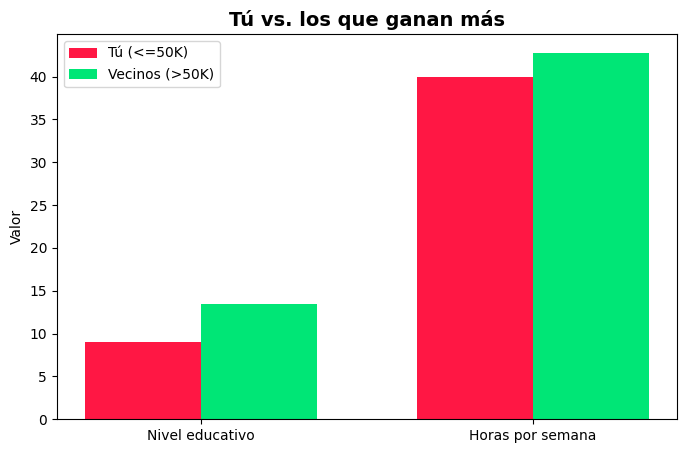

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Comparamos al usuario con la media de sus vecinos
categorias = ["Nivel educativo", "Horas por semana"]
valores_usuario = [user["education.num"].values[0], user["hours.per.week"].values[0]]
valores_vecinos = [vec["education.num"].mean(), vec["hours.per.week"].mean()]

x = np.arange(len(categorias))
ancho = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - ancho/2, valores_usuario, ancho, label="Tú (<=50K)", color="#FF1744")
plt.bar(x + ancho/2, valores_vecinos, ancho, label="Vecinos (>50K)", color="#00E676")

plt.title("Tú vs. los que ganan más", fontsize=14, fontweight="bold")
plt.ylabel("Valor")
plt.xticks(x, categorias)
plt.legend()
plt.show()

In [13]:
# Paso 5.1: Creamos una función reutilizable de recomendación

def recomendar(usuario_perfil):
   
    distancias, indices = modelo.kneighbors(usuario_perfil)
    vecinos = alto_ingreso.iloc[indices[0]]

    user = df_original.loc[usuario_perfil.index]
    vec = df_original.loc[vecinos.index]

    #  Mostramos el perfil del usuario
    print("PERFIL:", user["education"].values[0], "|",
          user["occupation"].values[0], "|",
          int(user["hours.per.week"].values[0]), "h/semana")
    print("Recomendaciones:")

    # Recomendaciones
    edu_u = user["education.num"].values[0]
    edu_v = vec["education.num"].mean()
    if edu_v > edu_u:
        print(f"  - Estudia más (tu nivel {edu_u} -> media vecinos {edu_v:.0f})")

    horas_u = user["hours.per.week"].values[0]
    horas_v = vec["hours.per.week"].mean()
    if horas_v > horas_u:
        print(f"  - Trabaja algo más ({int(horas_u)}h -> {horas_v:.0f}h)")

    ocup_top = vec["occupation"].mode()[0]
    if ocup_top != user["occupation"].values[0]:
        print(f"  - Ocupación sugerida: {ocup_top}")

    print()  

# Probamos la función con el primer usuario
recomendar(bajo_ingreso[columnas_perfil].iloc[[0]])

PERFIL: HS-grad | Prof-specialty | 40 h/semana
Recomendaciones:
  - Estudia más (tu nivel 9 -> media vecinos 13)
  - Trabaja algo más (40h -> 43h)



In [14]:
# Paso 5.2: Probamos con varios perfiles simulados

# Elegimos 3 perfiles de bajo ingreso bien distintos 
caso1 = df_original[(df_original["income"] == "<=50K") &
                    (df_original["age"] < 30) &
                    (df_original["education"] == "HS-grad")].index[0]

caso2 = df_original[(df_original["income"] == "<=50K") &
                    (df_original["age"].between(35, 50)) &
                    (df_original["hours.per.week"] < 30)].index[0]

caso3 = df_original[(df_original["income"] == "<=50K") &
                    (df_original["education"] == "Bachelors")].index[0]

casos = [caso1, caso2, caso3]

# Llamamos a la función con cada perfil
for idx in casos:
    recomendar(df.loc[[idx], columnas_perfil])

PERFIL: HS-grad | Sales | 40 h/semana
Recomendaciones:
  - Trabaja algo más (40h -> 47h)

PERFIL: HS-grad | Farming-fishing | 20 h/semana
Recomendaciones:
  - Trabaja algo más (20h -> 57h)

PERFIL: Bachelors | Prof-specialty | 55 h/semana
Recomendaciones:



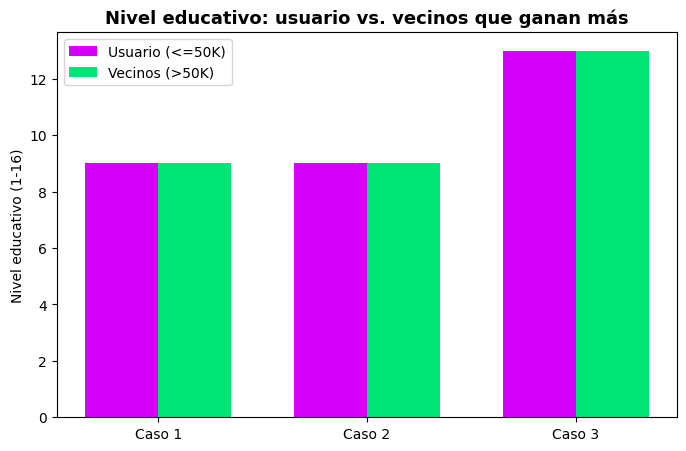

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Calculamos el nivel educativo del usuario vs el de sus vecinos para cada caso
edu_usuarios = []
edu_vecinos = []

for idx in casos:
    perfil = df.loc[[idx], columnas_perfil]
    distancias, indices = modelo.kneighbors(perfil)
    vecinos = alto_ingreso.iloc[indices[0]]
    edu_usuarios.append(df_original.loc[idx, "education.num"])
    edu_vecinos.append(df_original.loc[vecinos.index, "education.num"].mean())

etiquetas = ["Caso 1", "Caso 2", "Caso 3"]
x = np.arange(len(etiquetas))
ancho = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - ancho/2, edu_usuarios, ancho, label="Usuario (<=50K)", color="#D500F9")
plt.bar(x + ancho/2, edu_vecinos, ancho, label="Vecinos (>50K)", color="#00E676")

plt.title("Nivel educativo: usuario vs. vecinos que ganan más",
          fontsize=13, fontweight="bold")
plt.ylabel("Nivel educativo (1-16)")
plt.xticks(x, etiquetas)
plt.legend()
plt.show()